In [254]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.widgets import RangeSlider
from ipywidgets import interact, IntSlider, SelectionSlider
import requests
import warnings
from adjustText import adjust_text
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, q_stat
from arch.unitroot import PhillipsPerron
import statsmodels.api as smf
from IPython.display import display, Markdown, HTML
from sklearn.decomposition import PCA


warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pandas")

from pricing.pricer import PricerClass
from itertools import combinations
from calibration import Calibration
from tradescreener import tradeScreener
from plotting_utils import residuals_actualFitted, multipleResiduals, actualVsFittedCurve, \
    fittingErrorsHeatmap, threeFactorPlot, twoFactorPlot, factorsForwardsPlot, fittingErrorsHeatmap_fwd, \
    currentErrorsHeatmap_fwd

In [142]:
data = pd.read_csv("data/bankofengland/nominal/bankofengland_gilt_filtered.csv", index_col =0, parse_dates=True)
data = data.drop('0.75', axis=1)

Unfortunately, the 0.75y datapoint is missing for a few weeks in the recent period, so we drop it.

In [144]:
bankrate =pd.read_csv("data/bankofengland/bankrate.csv")
bankrate["Date"] = pd.to_datetime(bankrate["Date"], format="%d %b %y")
bankrate.columns = ['date', 'short']
bankrate.set_index('date', inplace=True)
bankrate.index = pd.to_datetime(bankrate.index)
bankrate.sort_index(inplace=True)

In [145]:
zeroCouponYields = pd.merge(bankrate, data, left_index=True, right_index=True, how = 'inner')
zeroCouponYields.columns = ['short'] + [float(x) for x in zeroCouponYields.columns if x != 'short']
zeroCouponYields.sort_index(inplace=True)

### 1. Calibration from 2014 to 2022, on yields below 25 yrs

In [256]:
sampleDates = ('2014-01-01', '2022-01-01')
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 25.5]

cal_2022 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [264]:
print('Calibrating between', termStructurePath.index[0].date(), 'and', termStructurePath.index[-1].date())
print('Using maturities from', cal_2022.maturities[0], 'to', cal_2022.maturities[-1], 'years.')

best_alpha_2022 =cal_2022.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))

best_sigma_2022 = cal_2022.calibrateSigma(alpha_r = best_alpha_2022['alpha_r'], 
                                alpha_m = best_alpha_2022['alpha_m'], 
                                alpha_l = best_alpha_2022['alpha_l'], 
                                initialGuess = [0.01092, 0.00964, 0.212])

best_mu_2022 = cal_2022.calibrateMu(alpha_r = best_alpha_2022['alpha_r'], 
                          alpha_m = best_alpha_2022['alpha_m'], 
                          alpha_l = best_alpha_2022['alpha_l'], 
                          sigma_m = best_sigma_2022['sigma_m'], 
                          sigma_l = best_sigma_2022['sigma_l'], 
                          rho = best_sigma_2022['rho'], 
                          initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')        # REMARK: Calibration here was done with 2y-fwd and 10y-fwd 1-year

AttributeError: 'numpy.ndarray' object has no attribute 'index'

To get OOS extracted factors, we re-feed the calibration class with the full dataset. We've calibrated all parameters on the in-sample piece of the data, so now we can operate on the full dataset to get OOS results.

In [290]:
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:None]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 25.5]

cal_2022 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [291]:
lf_full_2022 = cal_2022.extractLatentFactors_fwd(alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'], 
                         sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho'], mu = best_mu_2022['mu'])

estFactorsDf_full_2022 = pd.DataFrame(lf_full_2022, columns = ['medium', 'long'], index = zeroCouponYields[sampleDates[0]:None].index)
estFactorsDf_full_2022['short'] = termStructurePath['short']
estFactorsDf_full_2022 = estFactorsDf_full_2022[['short', 'medium', 'long']]
estFactorsDf_full_2022.iloc[-1]

short     3.750000
medium    1.422624
long      7.034851
Name: 2026-03-31 00:00:00, dtype: float64

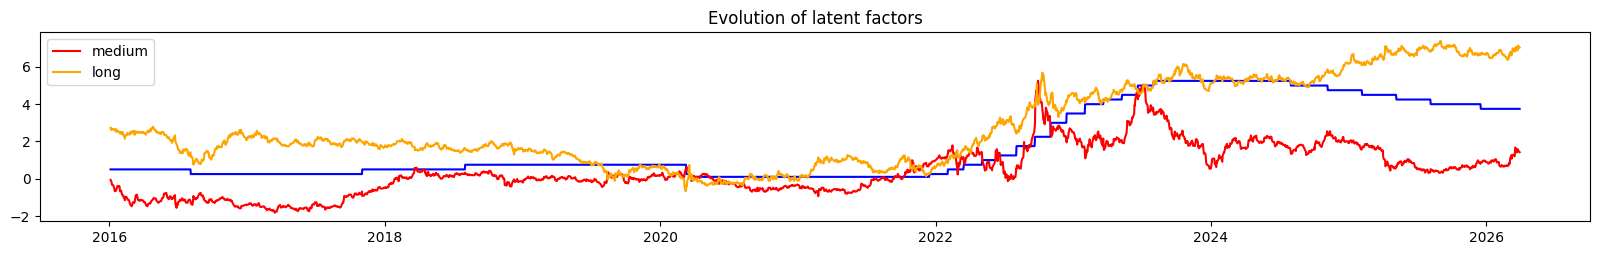

In [292]:
threeFactorPlot(estFactorsDf_full=estFactorsDf_full_2022)

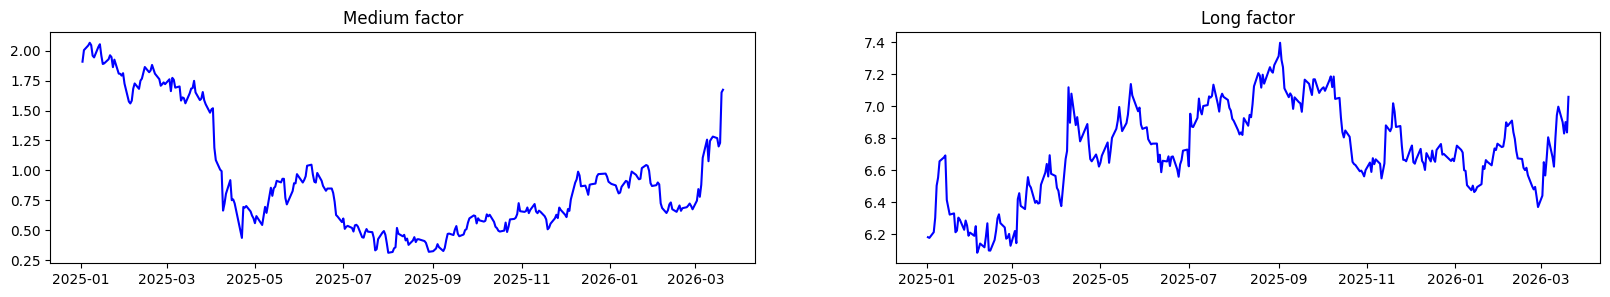

In [293]:
limits = ('2025-01-01', '2026-03-20')
twoFactorPlot(estFactorsDf_full=estFactorsDf_full_2022, limits = limits)

In [294]:
calParams_2022 = dict(alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'],
                  sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho'], mu = best_mu_2022['mu'])

fittedPricer_2022 = PricerClass(**calParams_2022)
fittedTs_full_2022 = [fittedPricer_2022.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full_2022.iloc[i].values)) for i in range(len(lf_full_2022))]
fittedTs_full_df_2022 = pd.DataFrame(fittedTs_full_2022, columns = MATURITIES, index = pd.to_datetime(termStructurePath.index))
fittedTs_full_df_2022.index = pd.to_datetime(fittedTs_full_df_2022.index)

In [295]:
fittingErrors_2022 = (fittedTs_full_df_2022 - termStructurePath).dropna(axis= 1)
fittingErrors_byYear_2022 = (fittingErrors_2022.groupby(fittingErrors_2022.index.year).apply(lambda x: np.sqrt((x**2).mean()).round(5))).T * 100

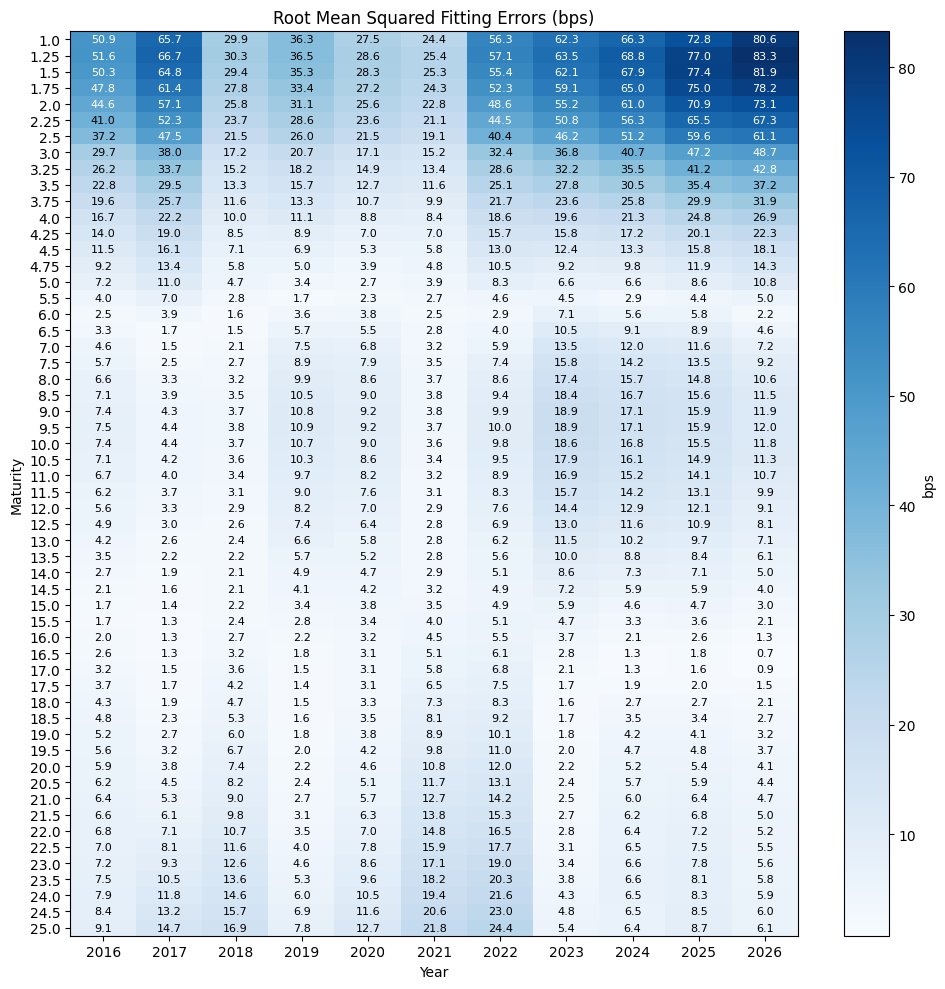

In [296]:
fittingErrorsHeatmap(fittingErrors_byYear=fittingErrors_byYear, figsize = (10, 10))

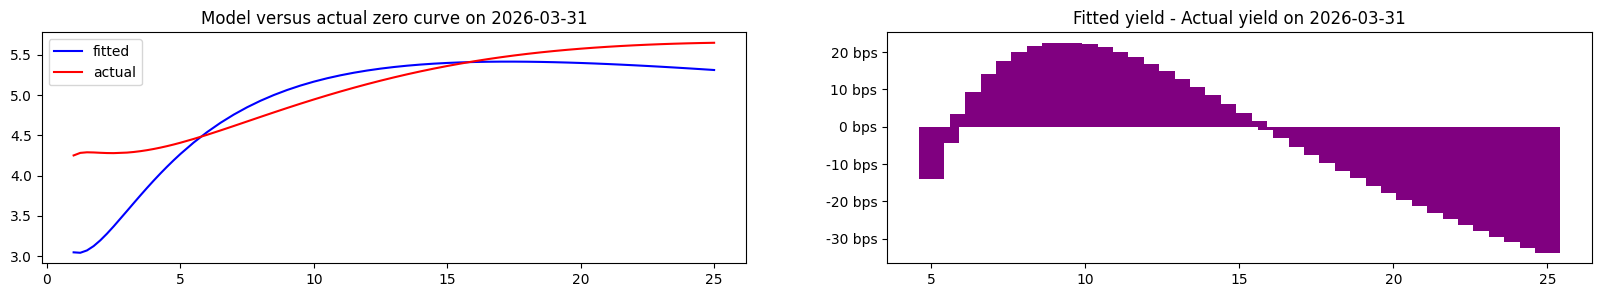

In [300]:
actualVsFittedCurve(targetDate='2026-03-31',
                    fittedTs_full_df=fittedTs_full_df_2022[[x for x in MATURITIES if x in fittedTs_full_df_2022.columns]],
                    termStructurePath=termStructurePath[[x for x in MATURITIES if x in fittedTs_full_df.columns] + ['short']],
                    tenorsAbove=4)

### 2. Calibration from 2016 to 2024, on yields up to 35 yrs

In [278]:
sampleDates = ('2016-01-01', '2024-01-01')
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 30.5]

print('Using maturities from', MATURITIES[0], 'to', MATURITIES[-1], 'years.')

cal_2024 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

Using maturities from 1.0 to 30.0 years.


In [279]:
print('Calibrating between', termStructurePath.index[0].date(), 'and', termStructurePath.index[-1].date())
print('Using maturities from', cal_2024.maturities[0], 'to', cal_2024.maturities[-1], 'years.')
best_alpha_2024 =cal_2024.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))

best_sigma_2024 = cal_2024.calibrateSigma(alpha_r = best_alpha_2024['alpha_r'], 
                                alpha_m = best_alpha_2024['alpha_m'], 
                                alpha_l = best_alpha_2024['alpha_l'], 
                                initialGuess = [0.01092, 0.00964, 0.212])

best_mu_2024 = cal_2024.calibrateMu(alpha_r = best_alpha_2024['alpha_r'], 
                          alpha_m = best_alpha_2024['alpha_m'], 
                          alpha_l = best_alpha_2024['alpha_l'], 
                          sigma_m = best_sigma_2024['sigma_m'], 
                          sigma_l = best_sigma_2024['sigma_l'], 
                          rho = best_sigma_2024['rho'], 
                          initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')        # REMARK: Calibration here was done with 2y-fwd and 10y-fwd 1-year

Calibrating between 2016-01-04 and 2023-12-29
Using maturities from 1.0 to 30.0 years.
alpha_r: 1.8800000000000012, alpha_m: 0.43444916303757536,               alpha_l: 0.013391627082086745, loss: 0.07071139913327996,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.0877908461446131, sigma_l: 0.07288320260245751, rho: 0.21409046495096667, loss: 4.164761399782935e-06, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 9.080443448223178, loss: 2370.471781514809, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


In [315]:
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:None]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 30.5]

cal_2024 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [316]:
lf_full_2024 = cal_2024.extractLatentFactors_fwd(alpha_r = best_alpha_2024['alpha_r'], alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'], 
                         sigma_m = best_sigma_2024['sigma_m'], sigma_l = best_sigma_2024['sigma_l'], rho = best_sigma_2024['rho'], mu = best_mu_2024['mu'])

estFactorsDf_full_2024 = pd.DataFrame(lf_full_2024, columns = ['medium', 'long'], index = termStructurePath.index)
estFactorsDf_full_2024['short'] = termStructurePath['short']
estFactorsDf_full_2024 = estFactorsDf_full_2024[['short', 'medium', 'long']]
estFactorsDf_full_2024.iloc[-1]

short     3.750000
medium    2.066471
long      5.966442
Name: 2026-03-31 00:00:00, dtype: float64

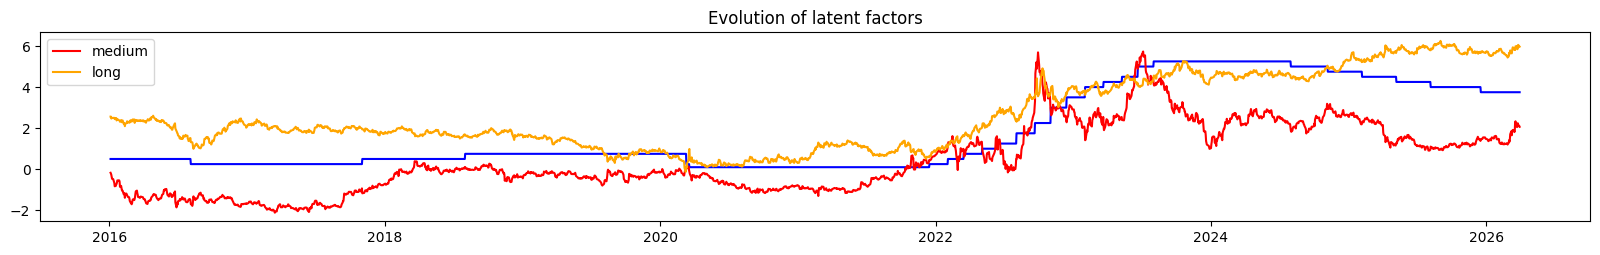

In [317]:
threeFactorPlot(estFactorsDf_full=estFactorsDf_full_2024)

In [318]:
calParams_2024 = dict(alpha_r = best_alpha_2024['alpha_r'], alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'],
                  sigma_m = best_sigma_2024['sigma_m'], sigma_l = best_sigma_2024['sigma_l'], rho = best_sigma_2024['rho'], mu = best_mu_2024['mu'])

fittedPricer_2024 = PricerClass(**calParams_2024)
fittedTs_full_2024 = [fittedPricer_2024.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full_2024.iloc[i].values)) for i in range(len(lf_full_2024))]
fittedTs_full_df_2024 = pd.DataFrame(fittedTs_full_2024, columns = MATURITIES, index = pd.to_datetime(termStructurePath.index))
fittedTs_full_df_2024.index = pd.to_datetime(fittedTs_full_df_2024.index)

fittingErrors_2024 = (fittedTs_full_df_2024 - termStructurePath).dropna(axis= 1)
fittingErrors_byYear_2024 = (fittingErrors_2024.groupby(fittingErrors_2024.index.year).apply(lambda x: np.sqrt((x**2).mean()).round(5))).T * 100

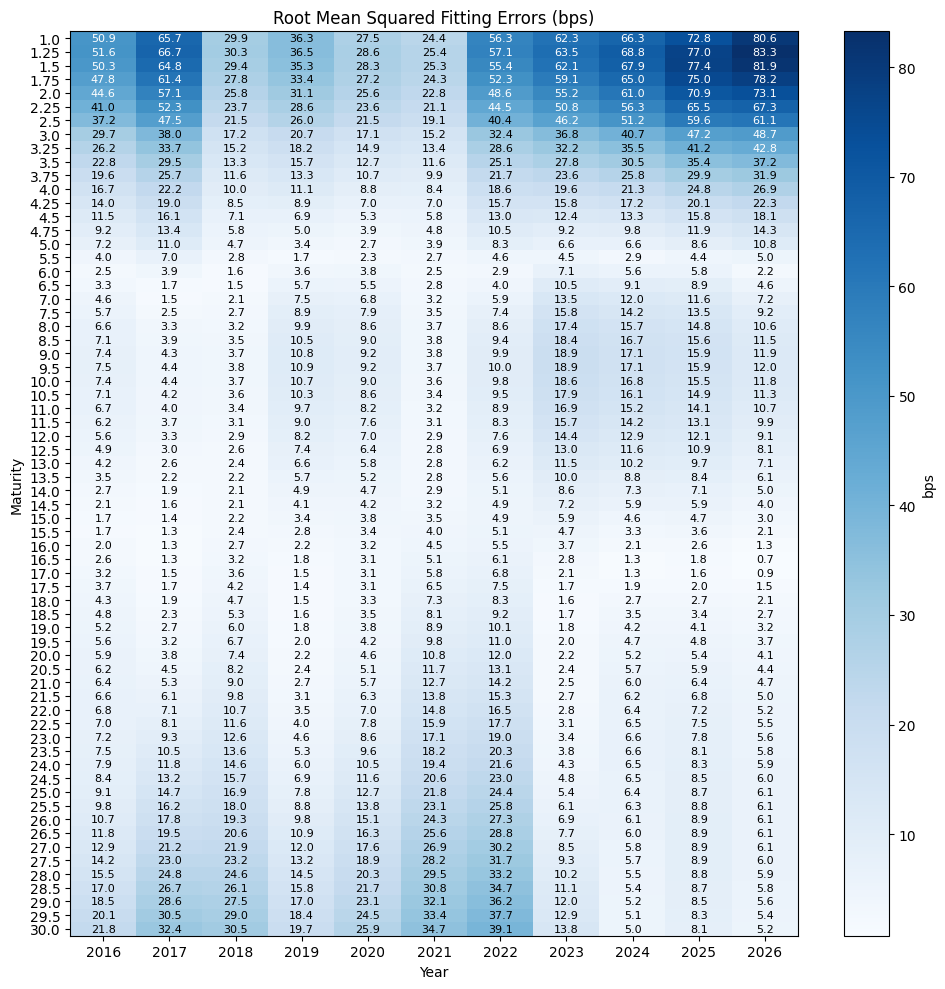

In [319]:
fittingErrorsHeatmap(fittingErrors_byYear=fittingErrors_byYear_2024, figsize = (10, 10))

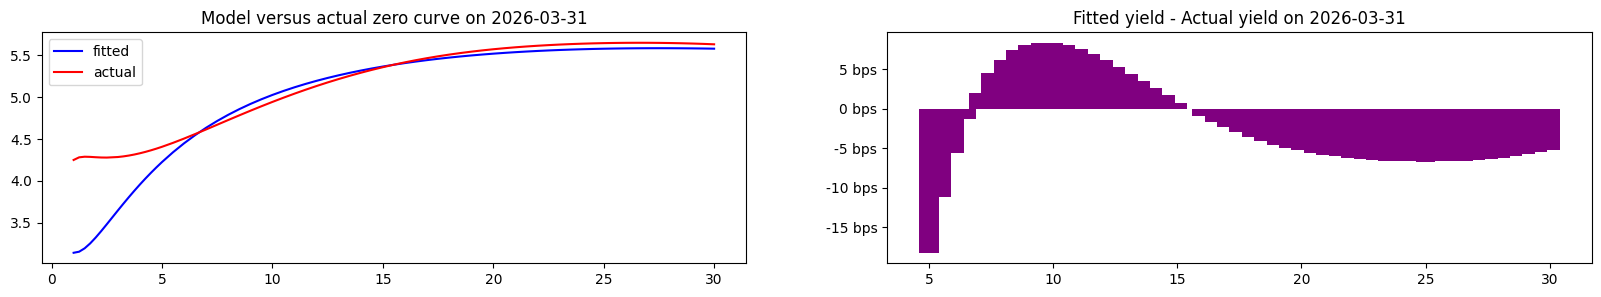

In [320]:
actualVsFittedCurve(targetDate='2026-03-31',
                    fittedTs_full_df=fittedTs_full_df_2024[[x for x in MATURITIES if x in fittedTs_full_df_2024.columns]],
                    termStructurePath=termStructurePath[[x for x in MATURITIES if x in fittedTs_full_df_2024.columns] + ['short']],
                    tenorsAbove=4)

### 3. Models backtest

In [323]:
screen = tradeScreener(modelData = fittedTs_full_df_2024,
                       actualData = zeroCouponYields,
                       maturitySet = [x for x in cal.maturities if int(x) > 0],
                       modelData_fwd= fittedTs_full_df_2024,         # PLEASE FEED FORWARDS IF YOU WANT TO SCREEN FOR FORWARDS
                       actualData_fwd= fittedTs_full_df_2024,
                       maturitySet_fwd=None)

In [324]:
outrightScreen = screen.outrightScreener()
slopeScreen = screen.slopeScreener()
flyScreen = screen.flyScreener()
# fwdScreen = screen.outrightScreener_fwd()

slopeDict = screen.buildSlopes()
flyDict = screen.buildFlies()

backtestParams = dict(
    startDt='2022-01-01', 
    endDt=None,
    shortW = 5, 
    longW = 40, 
    standardW=14
)

allOutrightBacktest = screen.allOutrightBacktest(**backtestParams)
allSlopeBacktest = screen.allSlopesBacktest(**backtestParams)
allFliesBacktest = screen.allFliesBacktest(**backtestParams)

topSlopes = allSlopeBacktest.round(3).sort_values(by='hitrate').tail(10).set_index('slope')
botSlopes = allSlopeBacktest.round(3).sort_values(by='hitrate').head(10).set_index('slope')
topFlies = allFliesBacktest.round(3).sort_values(by='hitrate').tail(10).set_index('fly')
botFlies = allFliesBacktest.round(3).sort_values(by='hitrate').head(10).set_index('fly')

In [326]:
overallHitRate = sum([(bt['hitrate'] * bt['n_trades']).sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])/sum([bt['n_trades'].sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])
overallSkew = sum([(bt['skew'] * bt['n_trades']).sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])/sum([bt['n_trades'].sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])
print(f'{"Strategy": <20} {"Tot Hit Rate": <20} {"Tot Skew": <20}')
print('----'*15)
for backtest, name in zip([allOutrightBacktest, allSlopeBacktest, allFliesBacktest], ['Outrights', 'Slopes', 'Flies']):
    print(f'{f'{name}:': <20} {(backtest['hitrate'] * backtest['n_trades'] / backtest['n_trades'].sum()).sum().round(4): <20}  {(backtest['skew'] * backtest['n_trades'] / backtest['n_trades'].sum()).sum().round(4): <20}\
          ')
print('----'*15)
print(f'{"Overall:": <20} {overallHitRate.round(4): <20}  {overallSkew.round(4): <20}')

    


Strategy             Tot Hit Rate         Tot Skew            
------------------------------------------------------------
Outrights:           0.4245                1.4938                        
Slopes:              0.3783                1.8088                        
Flies:               0.3149                1.3407                        
------------------------------------------------------------
Overall:             0.3616                1.6692              


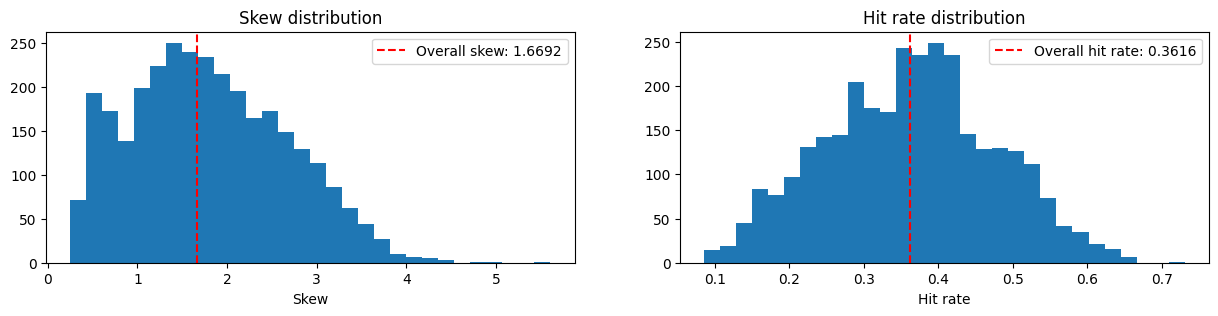

In [327]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 3))

ax[0].hist(pd.concat([allOutrightBacktest, allSlopeBacktest, allFliesBacktest])['skew'], bins = 30);
ax[0].set_title('Skew distribution')
ax[0].set_xlabel('Skew')
ax[0].axvline(overallSkew, color = 'red', linestyle = '--', label = f'Overall skew: {overallSkew.round(4)}');
ax[0].legend()
ax[1].hist(pd.concat([allOutrightBacktest, allSlopeBacktest, allFliesBacktest])['hitrate'], bins = 30);
ax[1].set_title('Hit rate distribution')
ax[1].set_xlabel('Hit rate')
ax[1].axvline(overallHitRate, color = 'red', linestyle = '--', label = f'Overall hit rate: {overallHitRate.round(4)}')
ax[1].legend();

In [328]:
display(Markdown("### Backtest of predictions on outright tenors\n\n" + 
    allOutrightBacktest.set_index('maturity').T.to_markdown(floatfmt=".3f")))

### Backtest of predictions on outright tenors

|             |    1.0 |   1.25 |    1.5 |   1.75 |    2.0 |   2.25 |    2.5 |    3.0 |   3.25 |    3.5 |   3.75 |    4.0 |   4.25 |    4.5 |   4.75 |    5.0 |    5.5 |    6.0 |    6.5 |    7.0 |    7.5 |    8.0 |    8.5 |    9.0 |    9.5 |   10.0 |   10.5 |   11.0 |   11.5 |   12.0 |   12.5 |   13.0 |   13.5 |   14.0 |   14.5 |   15.0 |   15.5 |   16.0 |   16.5 |   17.0 |   17.5 |   18.0 |   18.5 |   19.0 |   19.5 |   20.0 |   20.5 |   21.0 |   21.5 |   22.0 |   22.5 |   23.0 |   23.5 |   24.0 |   24.5 |   25.0 |   25.5 |   26.0 |   26.5 |   27.0 |   27.5 |   28.0 |   28.5 |   29.0 |   29.5 |   30.0 |
|:------------|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|
| hitrate     |  0.414 |  0.455 |  0.455 |  0.526 |  0.474 |  0.474 |  0.474 |  0.474 |  0.474 |  0.500 |  0.481 |  0.500 |  0.407 |  0.423 |  0.367 |  0.515 |  0.628 |  0.650 |  0.419 |  0.267 |  0.303 |  0.207 |  0.241 |  0.241 |  0.233 |  0.233 |  0.233 |  0.233 |  0.226 |  0.241 |  0.172 |  0.194 |  0.355 |  0.400 |  0.333 |  0.250 |  0.276 |  0.333 |  0.435 |  0.511 |  0.731 |  0.558 |  0.489 |  0.488 |  0.432 |  0.400 |  0.394 |  0.343 |  0.389 |  0.410 |  0.429 |  0.452 |  0.361 |  0.421 |  0.425 |  0.368 |  0.395 |  0.459 |  0.500 |  0.545 |  0.476 |  0.489 |  0.529 |  0.553 |  0.553 |  0.596 |
| skew        |  1.844 |  1.797 |  1.989 |  1.569 |  1.955 |  2.079 |  2.087 |  1.955 |  1.953 |  1.695 |  1.693 |  1.446 |  1.895 |  1.353 |  2.188 |  1.232 |  0.811 |  1.002 |  1.431 |  1.521 |  1.392 |  1.813 |  1.552 |  1.459 |  1.607 |  1.319 |  1.263 |  1.319 |  1.487 |  1.438 |  1.996 |  1.946 |  1.208 |  1.131 |  1.591 |  1.707 |  1.702 |  1.328 |  1.110 |  1.309 |  0.990 |  0.907 |  1.360 |  1.261 |  1.530 |  1.547 |  1.361 |  1.518 |  1.386 |  1.321 |  1.346 |  1.303 |  2.276 |  1.954 |  2.078 |  2.415 |  2.111 |  1.571 |  1.257 |  1.342 |  1.671 |  1.645 |  1.143 |  1.131 |  1.119 |  1.032 |
| avg days    | 22.379 | 29.045 | 27.545 | 31.105 | 31.053 | 30.842 | 30.842 | 31.053 | 31.053 | 29.500 | 21.889 | 21.429 | 22.074 | 22.192 | 18.467 | 14.758 |  9.977 | 13.000 | 22.871 | 23.200 | 21.515 | 26.172 | 26.552 | 26.862 | 27.033 | 27.267 | 27.267 | 27.267 | 26.194 | 26.897 | 26.862 | 23.806 | 23.226 | 23.433 | 20.121 | 22.464 | 23.759 | 18.121 | 11.435 |  7.979 |  7.231 | 10.256 | 10.978 | 11.884 | 13.703 | 14.171 | 15.121 | 14.343 | 13.889 | 13.000 | 12.214 | 12.333 | 14.306 | 13.684 | 13.075 | 13.737 | 13.921 | 14.162 | 13.175 | 12.250 | 13.143 | 12.128 | 11.784 | 13.064 | 13.191 | 13.468 |
| median days | 13.000 | 13.500 | 13.500 | 14.000 | 16.000 | 16.000 | 16.000 | 16.000 | 16.000 | 15.000 | 11.000 | 10.500 | 10.000 | 14.000 | 10.000 |  6.000 |  4.000 |  4.500 |  7.000 | 11.500 | 10.000 | 16.000 | 16.000 | 20.000 | 19.500 | 19.500 | 19.000 | 19.500 | 19.000 | 20.000 | 16.000 | 15.000 | 14.000 | 18.500 | 12.000 | 14.500 | 14.000 | 12.000 |  7.000 |  5.000 |  2.500 |  5.000 |  6.000 |  7.000 |  7.000 |  8.000 |  7.000 |  7.000 |  7.000 |  7.000 |  6.500 |  6.000 |  7.500 |  6.500 |  6.000 |  6.000 |  6.000 |  6.000 |  6.000 |  6.000 |  7.000 |  6.000 |  6.000 |  7.000 |  7.000 |  7.000 |
| n_trades    | 29.000 | 22.000 | 22.000 | 19.000 | 19.000 | 19.000 | 19.000 | 19.000 | 19.000 | 20.000 | 27.000 | 28.000 | 27.000 | 26.000 | 30.000 | 33.000 | 43.000 | 40.000 | 31.000 | 30.000 | 33.000 | 29.000 | 29.000 | 29.000 | 30.000 | 30.000 | 30.000 | 30.000 | 31.000 | 29.000 | 29.000 | 31.000 | 31.000 | 30.000 | 33.000 | 28.000 | 29.000 | 33.000 | 46.000 | 47.000 | 52.000 | 43.000 | 45.000 | 43.000 | 37.000 | 35.000 | 33.000 | 35.000 | 36.000 | 39.000 | 42.000 | 42.000 | 36.000 | 38.000 | 40.000 | 38.000 | 38.000 | 37.000 | 40.000 | 44.000 | 42.000 | 47.000 | 51.000 | 47.000 | 47.000 | 47.000 |

In [329]:
html = f"""
<div style="display:flex; gap:40px;">
  <div><h2>Top 10 Curve trades by hit rate</h2>{topSlopes.T.to_html()}</div>
  <div><h2>Worst 10 Curve trades by hit rate</h2>{botSlopes.T.to_html()}</div>
</div>
"""
display(HTML(html))

slope,19.0s28.0s,5.5s15.5s,21.5s24.5s,20.0s26.5s,19.5s27.0s,18.0s29.5s,21.0s25.0s,5.0s29.5s,20.5s25.5s,22.5s23.0s
hitrate,0.638,0.639,0.643,0.644,0.644,0.651,0.651,0.652,0.659,0.659
skew,0.947,0.991,0.858,0.882,0.870,0.973,0.874,0.777,0.844,0.774
avg days,14.511,13.056,16.095,15.200,15.000,15.837,15.698,14.457,15.227,14.886
median days,6.000,7.500,6.500,6.000,6.000,6.000,6.000,6.000,6.000,6.000
n_trades,47.000,36.000,42.000,45.000,45.000,43.000,43.000,46.000,44.000,44.000
slope,11.5s16.5s,12.0s16.0s,13.0s15.0s,12.5s15.5s,13.0s17.5s,12.5s18.0s,13.5s17.0s,15.0s16.0s,14.0s16.5s,14.5s17.0s
hitrate,0.103,0.103,0.105,0.105,0.105,0.105,0.105,0.108,0.108,0.114
skew,1.063,1.025,0.969,0.970,1.489,1.523,1.515,1.532,1.500,1.755
avg days,19.846,20.051,20.605,20.605,18.079,18.026,18.132,18.595,18.865,19.314
median days,10.000,11.000,11.000,11.000,8.000,8.500,8.000,13.000,13.000,13.000


In [330]:
html = f"""
<div style="display:flex; gap:40px;">
  <div><h2>Top 10 Fly trades by hit rate</h2>{topFlies.T.to_html()}</div>
  <div><h2>Worst 10 Fly trades by hit rate</h2>{botFlies.T.to_html()}</div>
</div>
"""
display(HTML(html))

fly,11.5s13.5s15.5s,6.0s18.0s30.0s,12.5s14.0s15.5s,7.5s15.0s22.5s,5.5s17.5s29.5s,9.0s14.5s20.0s,1.5s3.25s5.0s,12.0s13.5s15.0s,2.25s3.0s3.75s,1.5s3.5s5.5s
hitrate,0.593,0.600,0.600,0.603,0.613,0.614,0.615,0.627,0.636,0.641
skew,0.972,0.844,0.968,1.121,1.369,0.924,0.812,0.922,0.837,0.753
avg days,8.611,27.933,13.080,8.966,21.484,13.091,11.821,7.983,10.386,11.744
median days,4.000,19.500,6.000,5.000,8.000,5.500,7.000,5.000,4.000,3.000
n_trades,54.000,30.000,50.000,58.000,31.000,44.000,39.000,59.000,44.000,39.000
fly,8.5s12.0s15.5s,17.0s19.0s21.0s,18.5s19.0s19.5s,18.0s19.0s20.0s,17.5s19.0s20.5s,21.0s25.0s29.0s,20.5s25.0s29.5s,9.0s12.0s15.0s,15.5s19.5s23.5s,9.5s12.0s14.5s
hitrate,0.086,0.094,0.100,0.100,0.100,0.103,0.103,0.114,0.121,0.121
skew,1.621,0.619,0.561,0.559,0.570,0.832,0.841,1.496,0.450,1.432
avg days,21.457,28.656,30.700,30.667,30.667,23.483,23.517,21.143,27.909,22.091
median days,13.000,18.500,23.000,23.000,23.000,19.000,19.000,15.000,18.000,17.000


Text(0.5, 1.0, 'Outright trade screener')

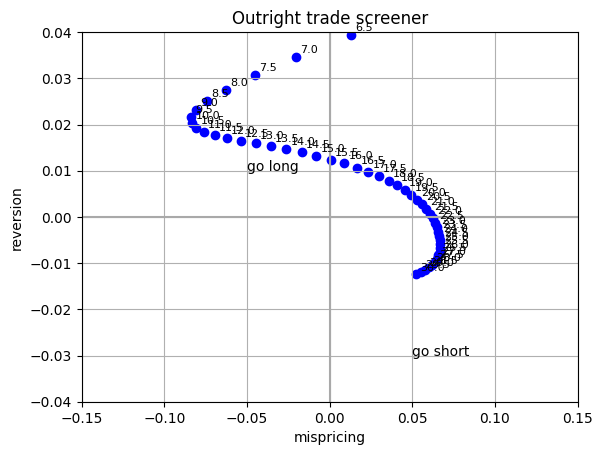

In [333]:
plt.axhline(y = 0, color = 'darkgrey')
plt.axvline(x = 0, color = 'darkgrey')
plt.scatter(outrightScreen['error'], outrightScreen['signal'], color = 'blue')
for i, txt in enumerate(outrightScreen.index):
    plt.annotate(txt,
                 (outrightScreen['error'].iloc[i], outrightScreen['signal'].iloc[i]),
                 xytext=(3,3),
                 textcoords='offset points',
                 fontsize=8)
plt.annotate(text = 'go short', xy = (0.05, - 0.03))
plt.annotate(text = 'go long', xy = (-0.05, + 0.01))
plt.xlim(-0.15, 0.15)
plt.ylim(-0.04, +0.04)
plt.xlabel('mispricing')
plt.ylabel('reversion')
plt.grid(True)
plt.title('Outright trade screener')

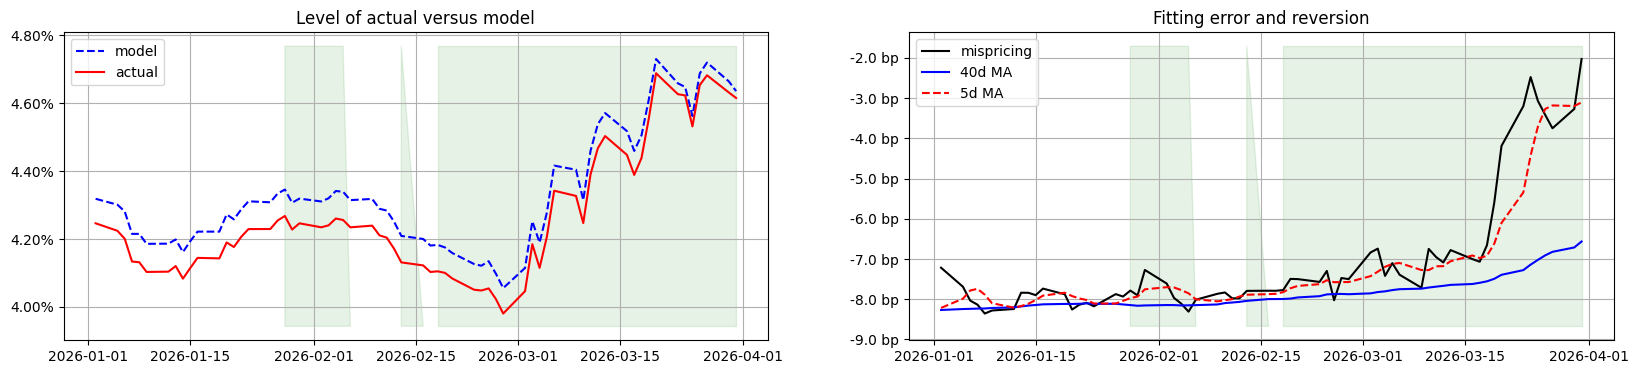

In [335]:
targetTenor = 7
screen.plotModelVsActual(modelSeries=screen.modelData[targetTenor],
                         actualSeries = screen.actualData[targetTenor],
                         shortW = 5, longW = 40, standardW = 14, leftPlotBp = False,
                         startDt = '2022-01-01', endDt = None,
                         display_startDt= '2026-01-01', display_endDt=None)

In [340]:
slopeScreen.loc[np.sign(slopeScreen['error']) * np.sign(slopeScreen['signal']) == -1].sort_values('error').head(10)

,model,actual,error,signal
23.0s27.0s,0.021224,0.021231,0.000007,-0.006735
24.5s25.5s,0.005192,0.005219,0.000027,-0.001695
23.5s26.5s,0.015758,0.015796,0.000038,-0.005067
24.0s26.0s,0.010429,0.010472,0.000043,-0.003385
24.5s25.0s,0.002882,0.003022,0.000139,-0.000863
9.0s10.5s,0.155927,0.156077,0.000150,-0.003831
7.5s13.0s,0.546189,0.546377,0.000188,-0.014769
9.5s10.0s,0.051825,0.052084,0.000259,-0.001252
24.0s24.5s,0.003479,0.003867,0.000388,-0.000893
8.0s12.0s,0.406341,0.406733,0.000391,-0.010463


In [341]:
slopeScreen.loc[np.sign(slopeScreen['error']) * np.sign(slopeScreen['signal']) == -1].sort_values('error').tail(10)

,model,actual,error,signal
10.0s24.0s,0.546388,0.696322,0.149934,-0.024436
10.0s26.0s,0.556817,0.706793,0.149977,-0.027822
9.5s24.0s,0.598213,0.748406,0.150193,-0.025689
9.5s26.0s,0.608642,0.758878,0.150236,-0.029074
10.0s24.5s,0.549867,0.700189,0.150322,-0.025330
10.0s25.5s,0.555059,0.705408,0.150349,-0.027024
10.0s25.0s,0.552749,0.703211,0.150462,-0.026193
9.5s24.5s,0.601692,0.752273,0.150582,-0.026582
9.5s25.5s,0.606883,0.757492,0.150609,-0.028277
9.5s25.0s,0.604574,0.755295,0.150721,-0.027445


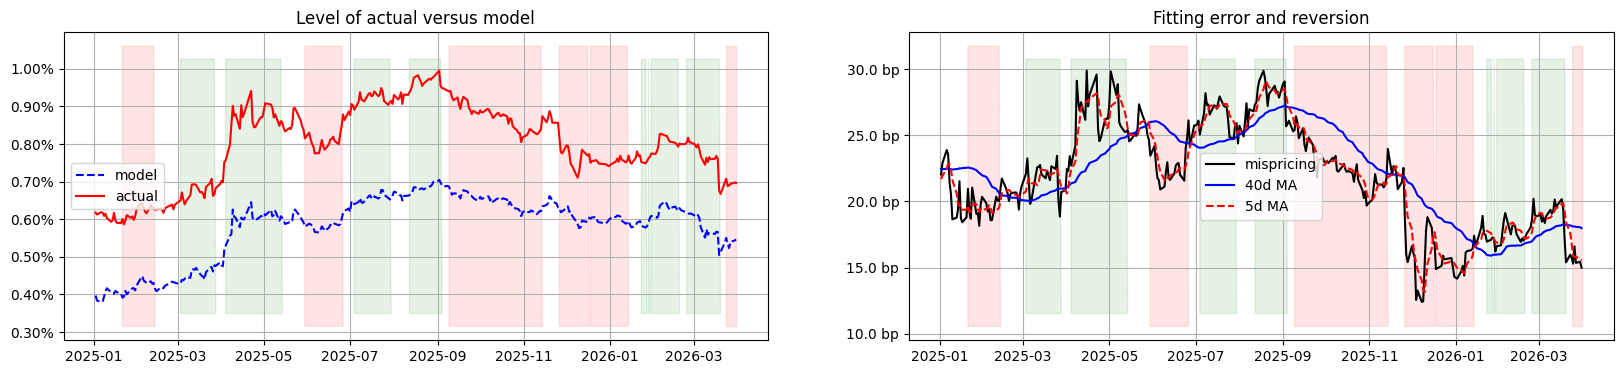

In [344]:
targetSlope = '10.0s24.0s'
screen.plotModelVsActual(modelSeries= slopeDict['model'][targetSlope],
                         actualSeries = slopeDict['actual'][targetSlope],
                         shortW = 5, longW = 40, standardW = 14, leftPlotBp = False,
                         startDt = '2022-01-01', endDt = None,
                         display_startDt= '2025-01-01', display_endDt=None)

In [345]:
screen.singleItemPerformance(modelSeries= slopeDict['model'][targetSlope],
                             actualSeries = slopeDict['actual'][targetSlope], 
                             **backtestParams)

,entry_date,exit_date,side,entry_misp,exit_misp,entry_signal,exit_signal,pnl,days,hit
0,2022-03-04,2022-04-12,LONG,-0.182156,-0.211918,0.000882,-0.001398,-0.029762,39,False
1,2022-05-19,2022-06-07,LONG,-0.189910,-0.231183,0.001695,-0.003143,-0.041273,19,False
2,2022-06-21,2022-07-25,LONG,-0.188525,-0.024641,0.006282,0.105515,0.163884,34,True
3,2022-08-02,2022-08-22,LONG,-0.078334,-0.086176,0.130165,-0.002133,-0.007842,20,False
4,2022-08-24,2022-09-01,LONG,-0.060927,-0.076621,0.001310,-0.001198,-0.015694,8,False
5,2022-09-02,2022-09-05,LONG,-0.047460,-0.076077,0.001233,-0.000345,-0.028617,3,False
6,2022-09-06,2022-09-09,LONG,-0.051998,0.019002,0.001413,0.026480,0.070999,3,True
7,2022-09-29,2022-10-03,LONG,-0.170373,-0.085478,0.139197,-0.012961,0.084894,4,True
8,2022-11-24,2022-11-25,SHORT,0.050632,0.032625,-0.003786,0.006056,0.018007,1,True
9,2023-01-04,2023-01-05,SHORT,0.056672,0.073150,-0.002627,0.002284,-0.016478,1,False


### 5. Time series of the residuals

In [226]:
oosFittingErrors = fittingErrors['2022-01-01':]

/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_13494/2109219032.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  ax[1].bar(fittingErrors.columns, oosFittingErrors.apply(lambda x: kpss(x.dropna(),regression='c')[1]));
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_13494/2109219032.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  ax[1].bar(fittingErrors.columns, oosFittingErrors.apply(lambda x: kpss(x.dropna(),regression='c')[1]));
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_13494/2109219032.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  ax[1].bar(fittingErrors.columns, oosFit

Text(0.5, 1.0, 'PP p-values')

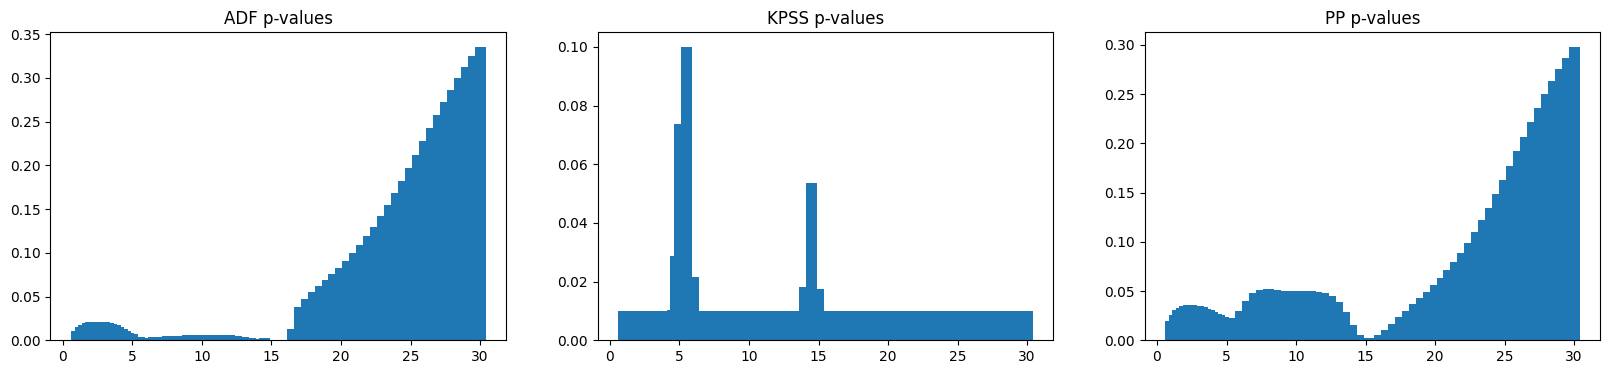

In [227]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 4))
ax[0].bar(fittingErrors.columns, oosFittingErrors.apply(lambda x: adfuller(x.dropna(), autolag = 'BIC', regression = 'c')[1]));
ax[0].set_title('ADF p-values')
ax[1].bar(fittingErrors.columns, oosFittingErrors.apply(lambda x: kpss(x.dropna(),regression='c')[1]));
ax[1].set_title('KPSS p-values')
ax[2].bar(fittingErrors.columns, oosFittingErrors.apply(lambda x: PhillipsPerron(x.dropna(), trend = 'c').pvalue));
ax[2].set_title('PP p-values')